In [1]:
# import requests
import pandas as pd
import numpy as np
# from scipy.stats import entropy
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf#, plot_pacf
# from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import root_mean_squared_error , mean_absolute_error , mean_absolute_percentage_error          

import holidays

# pd.options.display.float_format = '{:,.2f}'.format
import warnings
warnings.filterwarnings('ignore')  # Suppress all warnings

In [2]:
df = pd.read_csv("dataset_FINAL_all_variables.csv")

In [3]:
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')


In [4]:
df.TotSales

date
2014-02-01     78038658
2014-03-01     84094082
2014-04-01     86341669
2014-05-01     90493760
2014-06-01     90851778
                ...    
2025-09-01    207871871
2025-10-01    220481612
2025-11-01    219885862
2025-12-01    222564373
2026-01-01    202235203
Name: TotSales, Length: 144, dtype: int64

In [5]:
selected_cols = [
        #  'Anno'
        # , 'Mese'
         #  'GDPGrowth'
      #   , 'companies_trust'
         # 'GPL_price'
      'WorkingDays'
       , 'fixed_term'
      #  , 'permanent'
      #  , 'workforce'
      #  , 'inactives'
       , 'employment_rate'
       , 'youth_employment_rate'
      #  , 'activity_rate'
      #  , 'unemployment_rate'
       , 'industry_production_prices'
      #  , 'gasoline_car_price'
       , 'diesel_price'
       , 'TotSales']

In [6]:
df_selected = df[selected_cols]
df_selected.head(5)

,WorkingDays,fixed_term,employment_rate,youth_employment_rate,industry_production_prices,diesel_price,TotSales
date,,,,,,,
2014-02-01,20,2116627,38.64,54.49,93.0,1.63783,78038658
2014-03-01,21,2188435,38.81,55.42,92.8,1.63147,84094082
2014-04-01,20,2215274,37.57,54.69,92.6,1.62855,86341669
2014-05-01,21,2255743,39.78,55.44,92.5,1.63068,90493760
2014-06-01,20,2436989,39.38,55.90,92.7,1.63208,90851778


# 1. Fixed Term

## Training

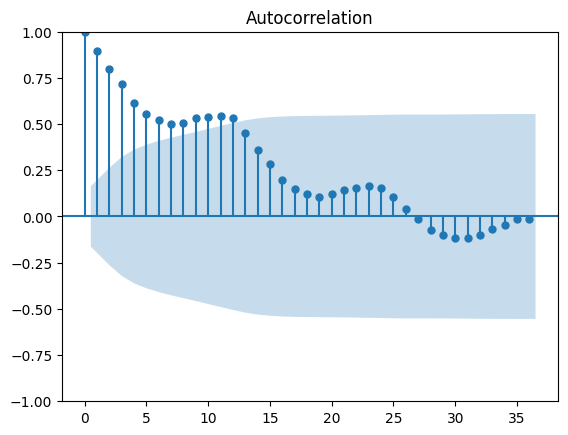

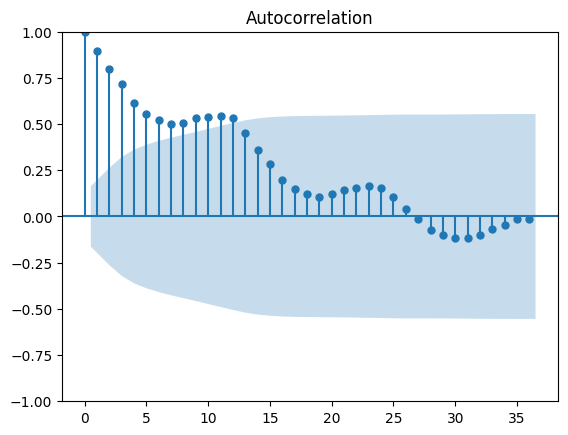

In [7]:
feature = 'fixed_term'

width = 10
height = 5

plot_acf(df_selected[feature],lags=36,alpha=0.05 )

In [8]:
test_staticist = adfuller(df_selected[feature])[0]
adf_criticatical_value_5perc = adfuller(df_selected[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_selected[f'{feature}_diff'] = df_selected[feature] - df_selected[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-2.34 > -2.88 ==> The time series is NON stationary


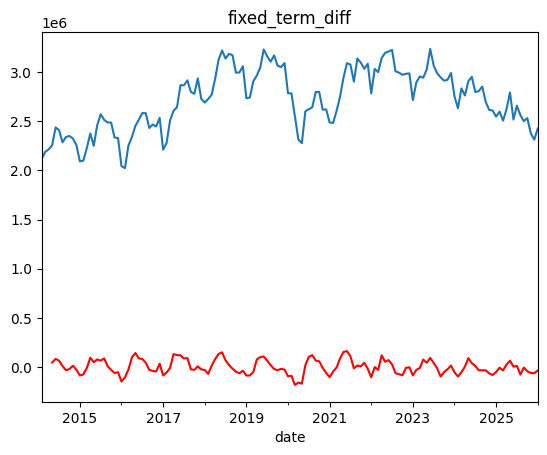

In [9]:
new_feature = f'{feature}_diff'

plt.title(new_feature)
rolling = df_selected[new_feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df_selected[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [10]:
df_train = df_selected[new_feature][5:-12]
df_test = df_selected[new_feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 13))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [11]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 87929.06
mae_test: 122848.44
mape_train: 2.39%
mape_test: 1.34%


### Forecasting

In [12]:
h = 12
model = ARIMA( endog=df_selected[new_feature]
              , order=(0, 0, 13))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_fixed_term = pd.DataFrame({f"{new_feature}": fcst})
df_fcst_fixed_term

,fixed_term_diff
2026-02-01,15471.651706
2026-03-01,-87412.031489
2026-04-01,93045.237354
2026-05-01,34390.012145
2026-06-01,-72542.308742
2026-07-01,62333.143744
2026-08-01,-66301.376140
2026-09-01,694.565713
2026-10-01,29955.990438
2026-11-01,-45283.394481


In [13]:
# df_selected = pd.concat([df_selected, df_fcst], axis = 0)
# df_selected

# 2. employment_rate

### Training

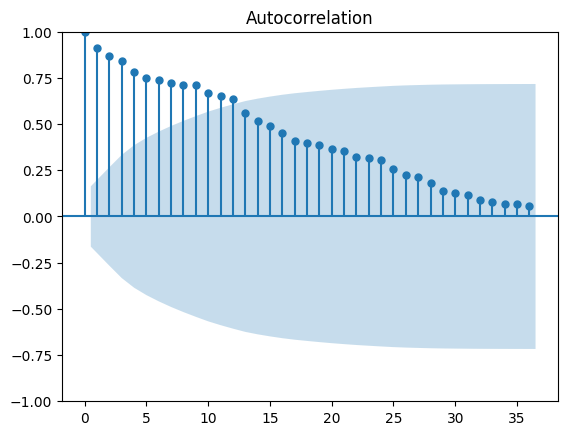

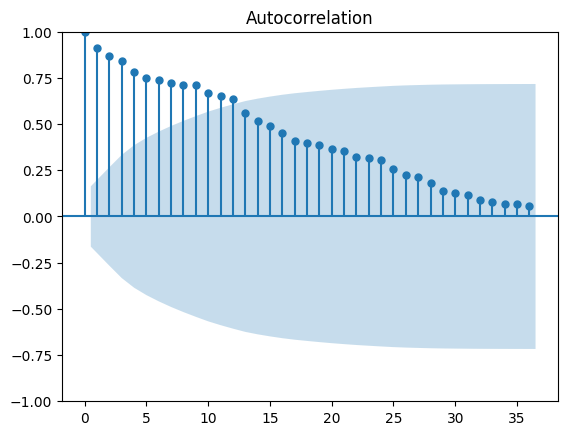

In [13]:
feature = 'employment_rate'

width = 10
height = 5

plot_acf(df_selected[feature],lags=36,alpha=0.05 )

In [14]:
test_staticist = adfuller(df_selected[feature])[0]
adf_criticatical_value_5perc = adfuller(df_selected[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_selected[f'{feature}_diff'] = df_selected[feature] - df_selected[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.79 > -2.88 ==> The time series is NON stationary


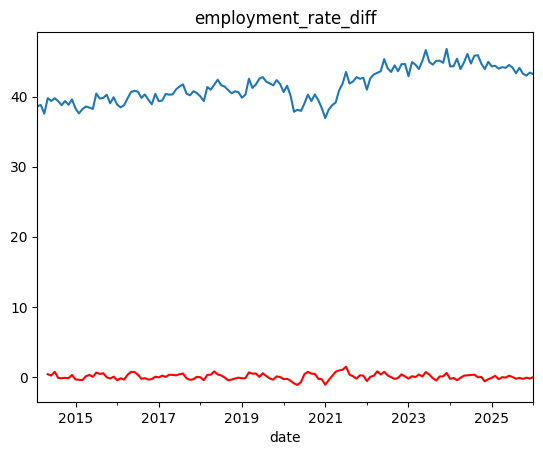

In [15]:
new_feature = f'{feature}_diff'

plt.title(new_feature)
rolling = df_selected[new_feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df_selected[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [16]:
df_train = df_selected[new_feature][5:-12]
df_test = df_selected[new_feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 13))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [17]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.63
mae_test: 0.67
mape_train: 1.77%
mape_test: 2.21%


### Forecasting

In [18]:
h = 12
model = ARIMA( endog=df_selected[new_feature]
              , order=(0, 0, 13))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_employment_rate = pd.DataFrame({f"{new_feature}": fcst})
df_fcst_employment_rate

,employment_rate_diff
2026-02-01,0.369272
2026-03-01,-0.055889
2026-04-01,0.248986
2026-05-01,-0.351388
2026-06-01,0.394600
2026-07-01,-0.165515
2026-08-01,-0.166902
2026-09-01,0.426909
2026-10-01,-0.256651
2026-11-01,0.277013


# 3. youth_employment_rate

### Training

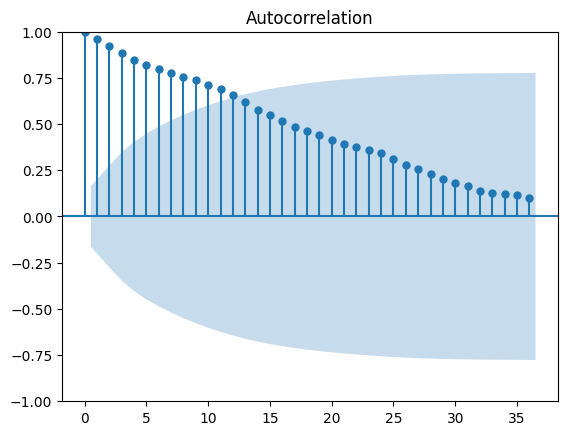

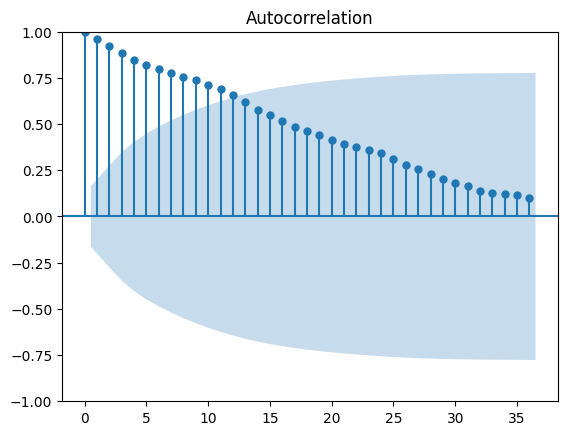

In [19]:
feature = 'youth_employment_rate'

width = 10
height = 5

plot_acf(df_selected[feature],lags=36,alpha=0.05 )

In [20]:
test_staticist = adfuller(df_selected[feature])[0]
adf_criticatical_value_5perc = adfuller(df_selected[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_selected[f'{feature}_diff'] = df_selected[feature] - df_selected[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.09 > -2.88 ==> The time series is NON stationary


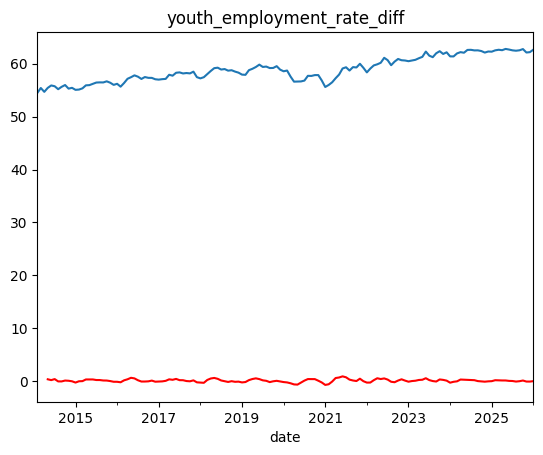

In [21]:
new_feature = f'{feature}_diff'

plt.title(new_feature)
rolling = df_selected[new_feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df_selected[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [22]:
df_train = df_selected[new_feature][5:-12]
df_test = df_selected[new_feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 12))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [23]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.34
mae_test: 0.24
mape_train: 3704844112267.2%
mape_test: 1.33%


### Forecasting

In [24]:
h = 12
model = ARIMA( endog=df_selected[new_feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_youth_employment_rate = pd.DataFrame({f"{new_feature}": fcst})
df_fcst_youth_employment_rate

,youth_employment_rate_diff
2026-02-01,0.070916
2026-03-01,-0.072849
2026-04-01,0.112974
2026-05-01,0.193818
2026-06-01,-0.061598
2026-07-01,0.003046
2026-08-01,-0.049084
2026-09-01,0.093122
2026-10-01,0.149186
2026-11-01,-0.101305


# 4. industry_production_prices

### Training

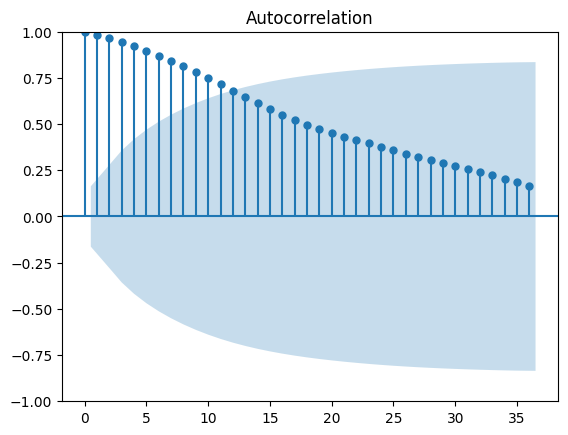

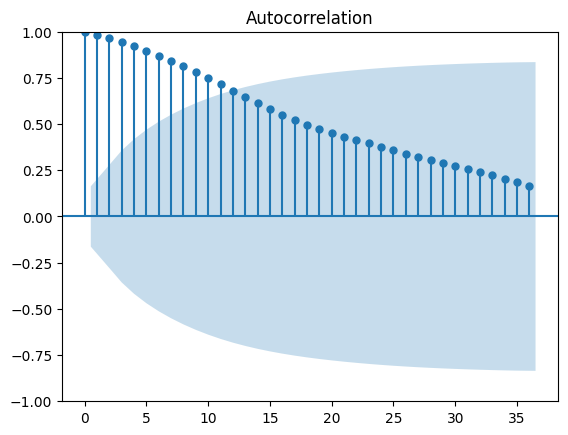

In [26]:
feature = 'industry_production_prices'

width = 10
height = 5

plot_acf(df_selected[feature],lags=36,alpha=0.05 )

In [27]:
test_staticist = adfuller(df_selected[feature])[0]
adf_criticatical_value_5perc = adfuller(df_selected[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_selected[f'{feature}_diff'] = df_selected[feature] - df_selected[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.7 > -2.88 ==> The time series is NON stationary


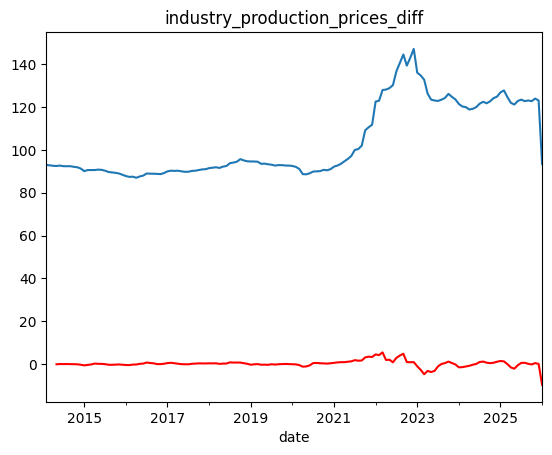

In [28]:
new_feature = f'{feature}_diff'

plt.title(new_feature)
rolling = df_selected[new_feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df_selected[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [29]:
df_train = df_selected[new_feature][5:-12]
df_test = df_selected[new_feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 12))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [30]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.98
mae_test: 3.72
mape_train: 74604699255203.11%
mape_test: 1.15%


### Forecasting

In [31]:
h = 12
model = ARIMA( endog=df_selected[new_feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_industry_production_prices = pd.DataFrame({f"{new_feature}": fcst})
df_fcst_industry_production_prices

,industry_production_prices_diff
2026-02-01,-10.329931
2026-03-01,-5.625128
2026-04-01,-9.734510
2026-05-01,-2.824013
2026-06-01,-8.995197
2026-07-01,-7.604572
2026-08-01,-3.252244
2026-09-01,-9.268802
2026-10-01,-1.439533
2026-11-01,-10.421015


# 5. diesel_price

### Training

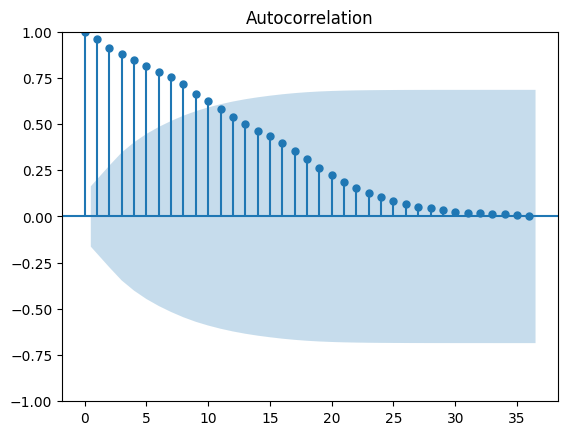

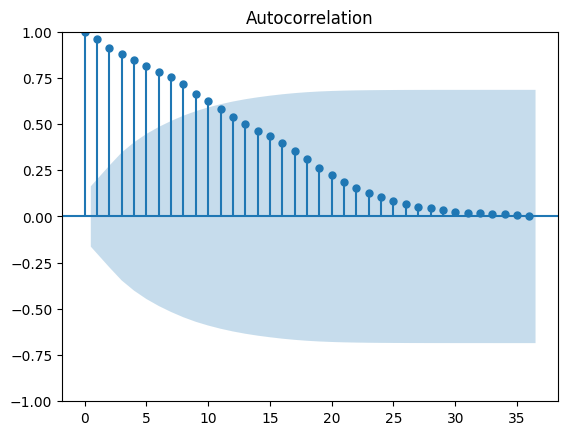

In [32]:
feature = 'diesel_price'

width = 10
height = 5

plot_acf(df_selected[feature],lags=36,alpha=0.05 ) 

In [33]:
test_staticist = adfuller(df_selected[feature])[0]
adf_criticatical_value_5perc = adfuller(df_selected[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_selected[f'{feature}_diff'] = df_selected[feature] - df_selected[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.41 > -2.88 ==> The time series is NON stationary


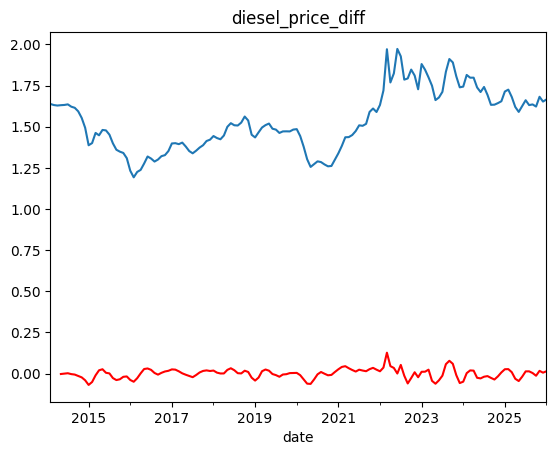

In [34]:
new_feature = f'{feature}_diff'

plt.title(new_feature)
rolling = df_selected[new_feature].rolling(window=3) #df[feature].rolling(window=3)
rolling_mean = rolling.mean()

# plot original and transformed dataset
df_selected[feature].plot()
rolling_mean.plot(color='red')
plt.show()

In [35]:
df_train = df_selected[new_feature][5:-12]
df_test = df_selected[new_feature][-12:]

model = ARIMA( endog=df_train
              , order=(0, 0, 11))

res = model.fit()

pred = res.predict()

fcst = res.forecast(steps = len(df_test))

In [36]:
mae_train = round(mean_absolute_error(df_train, pred),2)
mae_test =  round(mean_absolute_error(df_test, fcst),2)
mape_train =  round(mean_absolute_percentage_error(df_train, pred),2)
mape_test = round(mean_absolute_percentage_error(df_test, fcst),2)

print(f'mae_train: {mae_train}')
print(f'mae_test: {mae_test}')
print(f'mape_train: {mape_train}%')
print(f'mape_test: {mape_test}%')

mae_train: 0.03
mae_test: 0.03
mape_train: 3.76%
mape_test: 0.99%


### Forecasting

In [37]:
h = 12
model = ARIMA( endog=df_selected[new_feature]
              , order=(0, 0, 12))

res = model.fit()
fcst = res.forecast(steps = h)

df_fcst_diesel_price = pd.DataFrame({f"{new_feature}": fcst})
df_fcst_diesel_price

,diesel_price_diff
2026-02-01,0.024858
2026-03-01,-0.012986
2026-04-01,-0.007800
2026-05-01,0.015612
2026-06-01,0.003844
2026-07-01,0.015131
2026-08-01,-0.022622
2026-09-01,0.015705
2026-10-01,-0.012545
2026-11-01,0.005471


# Working days

In [38]:
year = 2026

# Italy holidays
it_holidays = holidays.country_holidays("IT", years=[year])

# Generate all days in the year
# dates = pd.date_range(start=f"{year}-01-01", end=f"{year}-12-31")
dates = pd.date_range(start="2026-01-01", end="2027-01-31")

df_days = pd.DataFrame({"date": dates})

# Weekday: Monday=0, Sunday=6
df_days["weekday"] = df_days["date"].dt.weekday

df_days["month_start"] = df_days["date"] - pd.offsets.MonthBegin(1) + pd.offsets.MonthBegin(0)

# Working day if weekday < 5 and not a holiday
df_days["is_working_day"] = (df_days["weekday"] < 5) & (~df_days["date"].isin(it_holidays))

# Count working days per month
monthly_working_days = df_days.groupby(df_days["date"].dt.month)["is_working_day"].sum()

df_days['WorkingDays'] = np.where(df_days['is_working_day']==True, 1, 0)

In [39]:
df_working_days = df_days[df_days['month_start']>'2026-01-01'].groupby('month_start')['WorkingDays'].sum().reset_index().rename(columns={'month_start':'date'}).set_index('date')


In [40]:
df_working_days

,WorkingDays
date,
2026-02-01,20
2026-03-01,23
2026-04-01,20
2026-05-01,21
2026-06-01,21
2026-07-01,22
2026-08-01,22
2026-09-01,22
2026-10-01,21


In [41]:
df_working_days_2014_2025 = df_selected['WorkingDays']

In [42]:
df_working_days_full = pd.concat([df_working_days_2014_2025, df_working_days], axis = 0)
df_working_days_full


,WorkingDays
date,
2014-02-01,20
2014-03-01,21
2014-04-01,20
2014-05-01,21
2014-06-01,20
...,...
2026-09-01,22
2026-10-01,21
2026-11-01,22


In [43]:
feature = 'WorkingDays'

test_staticist = adfuller(df_working_days_full[feature])[0]
adf_criticatical_value_5perc = adfuller(df[feature])[4]['5%']
if test_staticist > adf_criticatical_value_5perc:
    # non_stationary_cols.append(feature)
    print(f'{round(test_staticist,2)} > {round(adf_criticatical_value_5perc ,2)} ==> The time series is NON stationary')
    df_working_days_full[f'{feature}_diff'] = df_working_days_full[feature] - df_working_days_full[feature].shift( 1) # qui facciamo subito la differnziazione
else:    
    print(f'{round(test_staticist,2)} < {round(adf_criticatical_value_5perc ,2)} ==> The time series is STATIONARY')    

-1.63 > -2.88 ==> The time series is NON stationary


In [44]:
df_working_days_full

,WorkingDays,WorkingDays_diff
date,,
2014-02-01,20,NaN
2014-03-01,21,1.0
2014-04-01,20,-1.0
2014-05-01,21,1.0
2014-06-01,20,-1.0
...,...,...
2026-09-01,22,0.0
2026-10-01,21,-1.0
2026-11-01,22,1.0


# GENERATE FINAL DATASET

In [45]:
df_fcst = pd.concat([df_fcst_fixed_term, 
                     df_fcst_employment_rate,
                     df_fcst_youth_employment_rate, 
                     df_fcst_industry_production_prices,
                     df_fcst_diesel_price], axis = 1)
df_fcst

,fixed_term_diff,employment_rate_diff,youth_employment_rate_diff,industry_production_prices_diff,diesel_price_diff
2026-02-01,15471.651706,0.369272,0.070916,-10.329931,0.024858
2026-03-01,-87412.031489,-0.055889,-0.072849,-5.625128,-0.012986
2026-04-01,93045.237354,0.248986,0.112974,-9.734510,-0.007800
2026-05-01,34390.012145,-0.351388,0.193818,-2.824013,0.015612
2026-06-01,-72542.308742,0.394600,-0.061598,-8.995197,0.003844
2026-07-01,62333.143744,-0.165515,0.003046,-7.604572,0.015131
2026-08-01,-66301.376140,-0.166902,-0.049084,-3.252244,-0.022622
2026-09-01,694.565713,0.426909,0.093122,-9.268802,0.015705
2026-10-01,29955.990438,-0.256651,0.149186,-1.439533,-0.012545
2026-11-01,-45283.394481,0.277013,-0.101305,-10.421015,0.005471


In [46]:
df_selected.drop('WorkingDays', axis=1, inplace = True)

In [47]:
df_selected = pd.concat([df_selected, df_fcst], axis = 0)
df_selected = pd.concat([df_selected, df_working_days_full], axis = 1)
df_selected

,fixed_term,employment_rate,youth_employment_rate,industry_production_prices,diesel_price,TotSales,fixed_term_diff,employment_rate_diff,youth_employment_rate_diff,industry_production_prices_diff,diesel_price_diff,WorkingDays,WorkingDays_diff
2014-02-01,2116627.0,38.64,54.49,93.0,1.63783,78038658.0,NaN,NaN,NaN,NaN,NaN,20,NaN
2014-03-01,2188435.0,38.81,55.42,92.8,1.63147,84094082.0,71808.000000,0.170000,0.930000,-0.200000,-0.006360,21,1.0
2014-04-01,2215274.0,37.57,54.69,92.6,1.62855,86341669.0,26839.000000,-1.240000,-0.730000,-0.200000,-0.002920,20,-1.0
2014-05-01,2255743.0,39.78,55.44,92.5,1.63068,90493760.0,40469.000000,2.210000,0.750000,-0.100000,0.002130,21,1.0
2014-06-01,2436989.0,39.38,55.90,92.7,1.63208,90851778.0,181246.000000,-0.400000,0.460000,0.200000,0.001400,20,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-01,NaN,NaN,NaN,NaN,NaN,NaN,694.565713,0.426909,0.093122,-9.268802,0.015705,22,0.0
2026-10-01,NaN,NaN,NaN,NaN,NaN,NaN,29955.990438,-0.256651,0.149186,-1.439533,-0.012545,21,-1.0
2026-11-01,NaN,NaN,NaN,NaN,NaN,NaN,-45283.394481,0.277013,-0.101305,-10.421015,0.005471,22,1.0
2026-12-01,NaN,NaN,NaN,NaN,NaN,NaN,-18343.627018,0.060131,0.038082,-15.296791,-0.001798,21,-1.0


In [48]:
df_selected.to_csv('italy_revenues_PREDICTION_DATASET_v2_DIFFERENCED.csv')